# Normalizing flows verification

The goal of this notebook is to verify that normalizing flows is appropriate for transforming different distributions into a normal distribution while maintaining outlier structure.

In [0]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

from scipy import stats
from scipy.special import kv, gamma
from scipy.integrate import quad 
from scipy.optimize import brentq
from pingouin import multivariate_normality

import torch
import normflows as nf
from tqdm.notebook import tqdm

import seaborn as sns
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

In [0]:
sns.set_theme(style='white')

We define the main function to estimate the bijection to map from the complex \\(X\\)-space to the base distribution (Gaussian) \\(Z\\)-space. Note that the loss function is the sum of the \\(KL\\)-divergence and penalized by penalized by the logarithm of the non-unit Jacobian of the bijection squared with parameter \\(\lambda\\) in order to reduce wiggliness of the bijection. We attempt to match the target distribution (\\(p_\mathbf{X}(\mathbf{x}; \bm{\theta})\\)) with a flow-based model \\(p^*_\mathbf{X}(\mathbf{x}; \bm{\theta})\\) while penalizing for large movements required to approximate normality.

\\[\mathcal{L} = D_{KL}\left[ p^*_\mathbf{X}(\mathbf{x}) \|| p_\mathbf{X}(\mathbf{x}; \bm{\theta})\right] + \lambda \log^2 (|\det J(f|z)|), \\]

where \\(J\\) is the matrix of first derivatives (Jacobian) of \\(f\\).

In [0]:
def norm_flow(input_data, K, hidden_layers, hidden_units, iter, lam):

    # Number of bijections
    K = K

    # Latent size
    latent_size = input_data.shape[1]

    # NN architecture
    hidden_units = hidden_units
    hidden_layers = hidden_layers

    # Scale input data
    scaler = StandardScaler()
    input_data = scaler.fit_transform(input_data)

    # Set up the flows
    flows = []
    for i in range(K):
        flows += [nf.flows.AutoregressiveRationalQuadraticSpline(latent_size, hidden_layers, hidden_units, permute_mask=True, init_identity=True)]
        flows += [nf.flows.ActNorm(latent_size)]

    # Set base distribution
    q0 = nf.distributions.DiagGaussian(latent_size, trainable=False)
        
    # Construct flow model
    mod = nf.NormalizingFlow(q0, flows)

    device = torch.device('cuda')
    
    # Move model on GPU if available
    mod = mod.to(device)

    # Train model
    max_iter = iter
    optimizer = torch.optim.AdamW(mod.parameters(), lr=3e-4)

    x = torch.tensor(input_data, dtype=torch.float32, device=device)
    
    for it in tqdm(range(max_iter), desc='Normflow', position=1):
        optimizer.zero_grad()

        # Define the loss function
        _, jac = mod.inverse_and_log_det(x)
        loss = mod.forward_kld(x) + lam*torch.mean(jac**2)
        
        # Do backprop and optimizer step
        if ~(torch.isnan(loss) | torch.isinf(loss)):
            loss.backward()
            optimizer.step()

    # EZ = np.mean((x - mod.inverse(x)).to('cpu').detach().numpy()**2)
    # print("MSE from X to Z: ", EZ)
    with torch.no_grad():
        z = mod.inverse(torch.tensor(input_data, dtype=torch.float32, device=device)).to('cpu').detach().numpy()
    return mod, z

## Distribution for SHAP values

We begin with a chosen distribution as the SHAP values
- \\(1/2 \mathcal{N}(5, 1) + 1/2\mathcal{N}(1, 1.3^2)\\)
- \\(\chi^2_{10}\\)
- \\(t_{10}\\)

In [0]:
n = 10000
np.random.seed(123)

In [0]:
dbutils.widgets.dropdown("Distribution", "bimodal", list(["bimodal", "chi2", "t"]))
dist = dbutils.widgets.get("Distribution")

In [0]:
if dist=='bimodal':
    # Parameters of the mixture components
    norm_params = np.array([[5, 1], [1, 1.3]])
    n_components = norm_params.shape[0]
    weights = np.ones(n_components, dtype=np.float64) / 2.0

    # Sample from the mixture
    mixture_idx = np.random.choice(len(weights), size=n, replace=True, p=weights)
    X_data = np.fromiter((stats.norm.rvs(*(norm_params[i])) for i in mixture_idx), dtype=np.float64).reshape(-1, 1)

elif dist=='chi2':
    X_data = stats.chi2.rvs(10, size=n).reshape(-1, 1)

else:
    X_data = stats.t.rvs(10, size=n).reshape(-1, 1)

<Axes: >

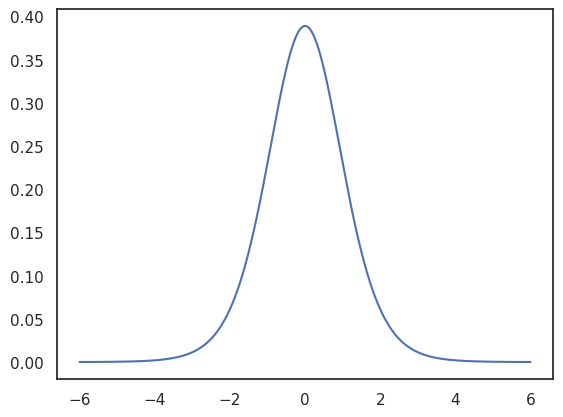

In [0]:
# Plotting
if dist=='bimodal':
    x = np.linspace(-4,10,1000)
    y_plot = 0.5*stats.norm.pdf(x,*norm_params[0]) + 0.5*stats.norm.pdf(x,*norm_params[1])

elif dist == 'chi2':
    x = np.linspace(0,40,1000)
    y_plot = stats.chi2.pdf(x, 10)

else:
    x = np.linspace(-6,6,1000)
    y_plot = stats.t.pdf(x, 10)
    
sns.lineplot(x=x, y=y_plot)

We apply the normalizing flow to the SHAP values by first tuning \\(\lambda\\).

In [0]:
# Specify the parameters
if dist=='t':
    K, hidden_units, hidden_layers = 8, 8, 2
elif dist=='bimod':
    K, hidden_units, hidden_layers = 4, 4, 2
else:
    K, hidden_units, hidden_layers = 6, 6, 2

In [0]:
# Tune lambda
for j, i in enumerate(np.concatenate([np.array([0]), np.exp(np.linspace(-5,1,10))])):
    print("lambda: ", i)
    mod, z = norm_flow(X_data, 
                       K, 
                       hidden_layers, 
                       hidden_units, 
                       500, 
                       i)

    print(stats.jarque_bera(z.reshape(-1)))

    pval = stats.jarque_bera(z.reshape(-1)).pvalue

    if pval < 0.01:
        break

lam = np.concatenate([np.array([0]), np.exp(np.linspace(-5,1,10))])[j-1]
print("Final lambda: ", lam)

lambda:  0.0


Normflow:   0%|          | 0/500 [00:00<?, ?it/s]

MSE from X to Z:  0.004315225
SignificanceResult(statistic=1.392126864804168, pvalue=0.4985439981448603)
lambda:  0.006737946999085467


Normflow:   0%|          | 0/500 [00:00<?, ?it/s]

MSE from X to Z:  0.004086427
SignificanceResult(statistic=2.386207305776344, pvalue=0.3032785305773511)
lambda:  0.013123728736940968


...

MSE from X to Z:  0.0038762894
SignificanceResult(statistic=3.6207079864326035, pvalue=0.16359621460109428)
lambda:  0.09697196786440505


Normflow:   0%|          | 0/500 [00:00<?, ?it/s]

MSE from X to Z:  0.003596267
SignificanceResult(statistic=5.839657873081188, pvalue=0.053942914172651964)
lambda:  0.18887560283756177


Normflow:   0%|          | 0/500 [00:00<?, ?it/s]

MSE from X to Z:  0.003028614
SignificanceResult(statistic=13.350705657657755, pvalue=0.0012616273687995154)
Final lambda:  0.09697196786440505


In [0]:
N = 1000

y_final = {}
counter = 0
for i in tqdm(range(N), desc='Simulation', position=0):

    mod, z = norm_flow(X_data, K, hidden_layers, hidden_units, 500, lam)

    # Assess normality
    print(stats.jarque_bera(z.reshape(-1)))

    if stats.jarque_bera(z.reshape(-1)).pvalue > 0.01:
        counter += 1
        x_ = np.linspace(-6, 6, 10000)
        with torch.no_grad():
            y_transformed = mod.forward(torch.tensor(x_.reshape(-1,1), 
                                                    dtype=torch.float32, 
                                                    device='cuda')) \
                                                        .to('cpu')\
                                                        .detach() \
                                                        .numpy() \
                                                        .reshape(-1)
        
        y_final[i] =  pd.Series(y_transformed)
        
y_final = pd.concat(list(y_final.values()), axis=1)

Simulation:   0%|          | 0/2 [00:00<?, ?it/s]

Normflow:   0%|          | 0/500 [00:00<?, ?it/s]

MSE from X to Z:  0.0035997368
SignificanceResult(statistic=6.095076506235424, pvalue=0.04747565369565983)


Normflow:   0%|          | 0/500 [00:00<?, ?it/s]

MSE from X to Z:  0.003555406
SignificanceResult(statistic=6.146675852249435, pvalue=0.046266462790866575)


In [0]:
y_final_boot = {}
counter_boot = 0
for i in tqdm(range(N), desc='Simulation', position=0):

    X_data_2 = np.random.choice(X_data.reshape(-1), X_data.shape[0])
    mod_boot, z_boot = norm_flow(X_data_2.reshape(-1, 1), 
                                 K,
                                 hidden_layers, 
                                 hidden_units,
                                 500, 
                                 lam)

    # Assess normality
    print(stats.jarque_bera(z_boot.reshape(-1)))

    if stats.jarque_bera(z_boot.reshape(-1)).pvalue > 0.01:
        counter_boot += 1
        x_ = np.linspace(-6, 6, 10000)
        with torch.no_grad():
            y_transformed_boot = mod_boot.forward(torch.tensor(x_.reshape(-1,1), 
                                                            dtype=torch.float32, 
                                                            device='cuda')) \
                                                                .to('cpu') \
                                                                .detach() \
                                                                .numpy() \
                                                                .reshape(-1)

        y_final_boot[i] = pd.Series(y_transformed_boot)
        

y_final_boot = pd.concat(list(y_final_boot.values()), axis=1)


Simulation:   0%|          | 0/2 [00:00<?, ?it/s]

Normflow:   0%|          | 0/500 [00:00<?, ?it/s]

MSE from X to Z:  0.0041165734
SignificanceResult(statistic=9.095256609135037, pvalue=0.010592296317674638)


Normflow:   0%|          | 0/500 [00:00<?, ?it/s]

MSE from X to Z:  0.0025252202
SignificanceResult(statistic=3.316227511272622, pvalue=0.19049796714325948)


In [0]:
print("Number of passes:", counter, counter_boot)

We calculate and plot the transformation with varying the random seed as well as using the bootstrap.

/root/.ipykernel/1612/command-1390665270483836-739041547:4: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data=y_final_plot.melt(id_vars='x'),


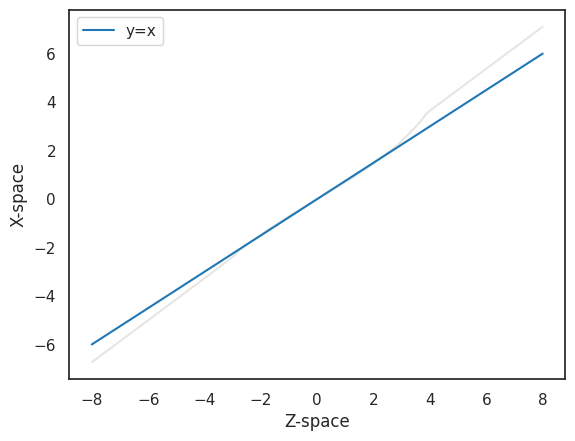

In [0]:
# Plotting transformation with varying seed
y_final_plot = y_final
y_final_plot['x'] = np.linspace(-6, 6, 10000)
sns.lineplot(data=y_final_plot.melt(id_vars='x'), 
             x="x", 
             y="value", 
             hue='variable', 
             palette=['black'], 
             legend=False, 
             alpha=0.05) \
                 .set(xlabel='Z-space', ylabel='V-space')

plt.plot([-6,6], [-6, 6], label='y=x', color='#1f77b4')

plt.legend(loc="upper left")

/root/.ipykernel/1612/command-1390665270483837-503844746:4: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data=y_final_plot_boot.melt(id_vars='x'),


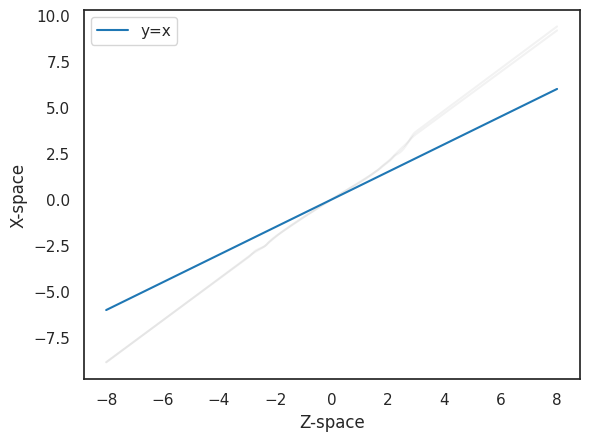

In [0]:
# Plotting transformation with varying seed
y_final_plot_boot = y_final_boot
y_final_plot_boot['x'] = np.linspace(-6, 6, 10000)
sns.lineplot(data=y_final_plot_boot.melt(id_vars='x'), 
             x="x", 
             y="value", 
             hue='variable', 
             palette=['black'], 
             legend=False, 
             alpha=0.05) \
                 .set(xlabel='Z-space', ylabel='V-space')

plt.plot([-6,6], [-6, 6], label='y=x', color='#1f77b4')

plt.legend(loc="upper left")

And plotting the transformed distribution.

Normflow:   0%|          | 0/500 [00:00<?, ?it/s]

MSE from X to Z:  0.0036324342


<Axes: ylabel='Count'>

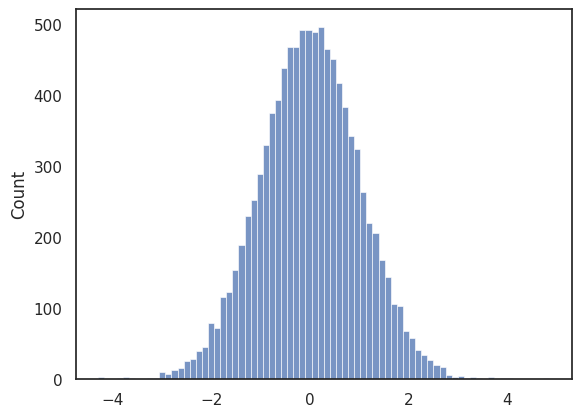

In [0]:
mod, z = norm_flow(X_data, K, hidden_layers, hidden_units, 500, lam)
sns.histplot(z.reshape(-1), legend=False)